### Вопрос 1: Топ-10 исполнителей по прибыли с разбивкой по жанрам


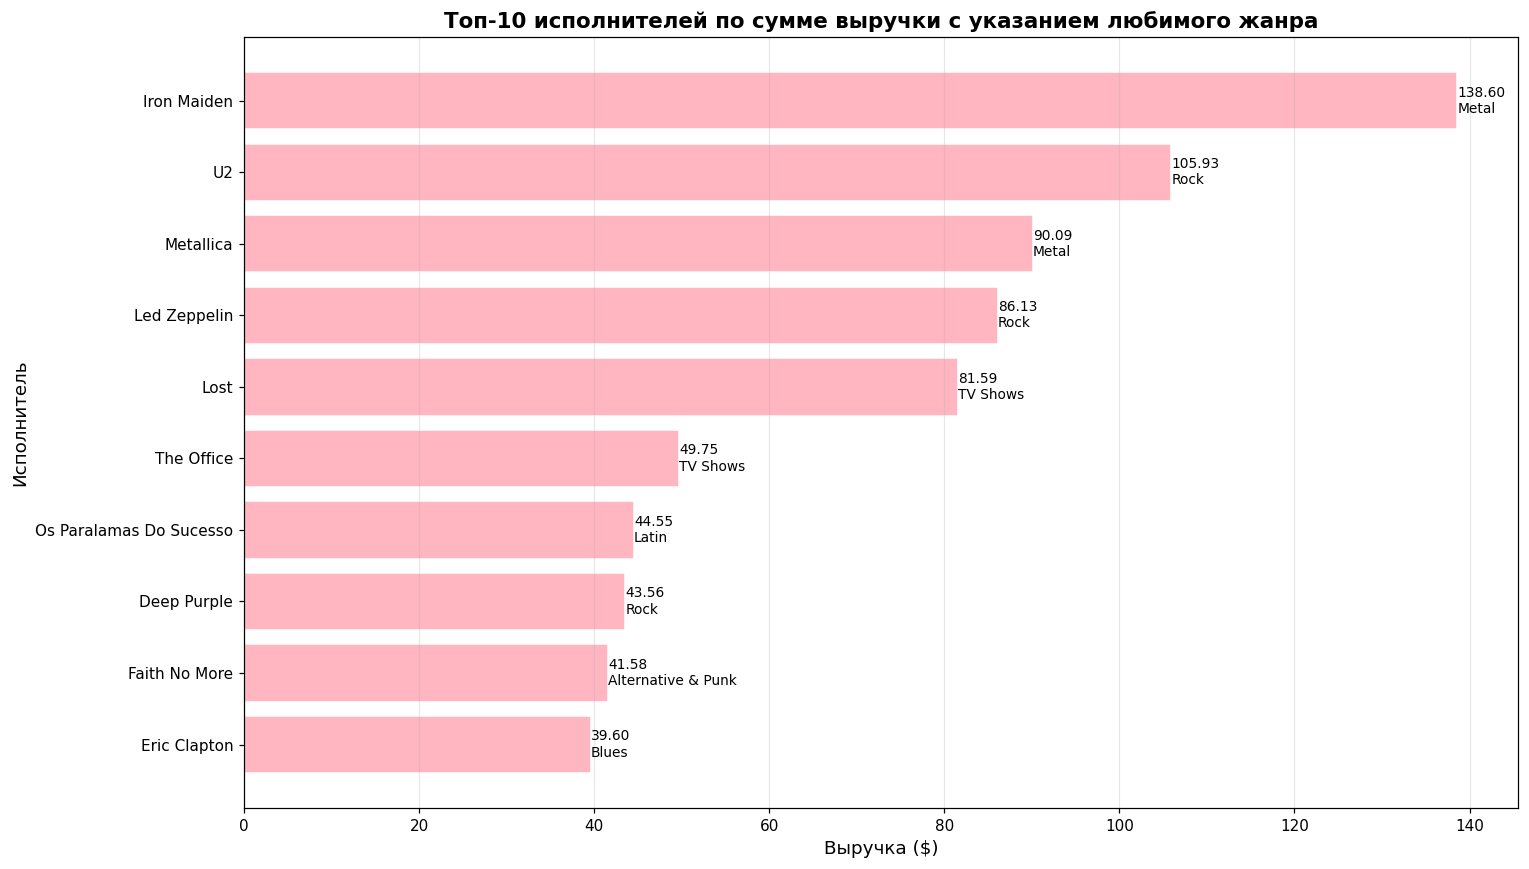

In [ ]:
# ИТОГ Q1: Топ-10 исполнителей по выручке
# Таблицы: Artist → Album → Track → InvoiceLine
# Бонус: добавьте жанр (Genre) к каждому исполнителю (MOST POPULAR genre)
# Визуализация: горизонтальный bar chart

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings

conn = sqlite3.connect("tgu_practice_db.db")
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["figure.dpi"]  = 110
warnings.filterwarnings("ignore")

def sql(query):
    return pd.read_sql_query(query, conn)

# TODO: SQL
query_q1 = """
-- Выручка по каждому треку с информацией об исполнителе и жанре
WITH track_revenue AS (
    SELECT 
        Artist.ArtistId,
        Artist.Name AS Artist,
        Genre.Name AS Genre,
        SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity) AS Revenue
    FROM InvoiceLine
    JOIN Track ON InvoiceLine.TrackId = Track.TrackId
    JOIN Album ON Track.AlbumId = Album.AlbumId
    JOIN Artist ON Album.ArtistId = Artist.ArtistId
    JOIN Genre ON Track.GenreId = Genre.GenreId
    GROUP BY Artist.ArtistId, Genre.GenreId
),
-- Для каждого исполнителя – самый доходный жанр (по выручке)
best_genre AS (
    SELECT 
        ArtistId,
        Artist,
        Genre,
        Revenue AS GenreRevenue,
        ROW_NUMBER() OVER (PARTITION BY ArtistId ORDER BY Revenue DESC) AS rn
    FROM track_revenue
),
-- Общая выручка по исполнителям (сумма по всем жанрам)
total_revenue AS (
    SELECT 
        ArtistId,
        Artist,
        SUM(Revenue) AS TotalRevenue
    FROM track_revenue
    GROUP BY ArtistId
)
-- Финальный результат: топ-10 исполнителей по общей выручке, с их любимым жанром
SELECT 
    total_revenue.Artist,
    ROUND(total_revenue.TotalRevenue, 2) AS Выручка_USD,
    best_genre.Genre AS Любимый_жанр
FROM total_revenue 
JOIN best_genre ON total_revenue.ArtistId = best_genre.ArtistId AND best_genre.rn = 1
ORDER BY total_revenue.TotalRevenue DESC
LIMIT 10
"""

df_top_artists = sql(query_q1)

# TODO: matplotlib
# Сортировка по убыванию выручки 
df_plot = df_top_artists.sort_values('Выручка_USD', ascending=True)

plt.figure(figsize=(14, 8))
bars = plt.barh(df_plot['Artist'], df_plot['Выручка_USD'], 
                color='lightpink', edgecolor='white')
plt.xlabel('Выручка ($)', fontsize=12)
plt.ylabel('Исполнитель', fontsize=12)
plt.title('Топ-10 исполнителей по сумме выручки с указанием любимого жанра', 
          fontsize=14, fontweight='bold')
# Аннотации жанров справа от столбцов
for i, (idx, row) in enumerate(df_plot.iterrows()):
    label = f"{row['Выручка_USD']:.2f}\n{row['Любимый_жанр']}"
    plt.text(row['Выручка_USD'], i, label, va='center', ha='left', fontsize=9)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('top_artists_revenue.png', dpi=120, bbox_inches='tight')
plt.show()

# TODO: Markdown-вывод — напишите ниже ячейку Markdown:
# «Лидер по выручке — ??? с суммой $??? ...»


Лидер по выручке — Iron Maiden с суммой 138.60$.  
На втором месте U2 – 105.93$, на третьем Metallica – 90.09$.

### Вопрос 2: Квартальная выручка и сезонность


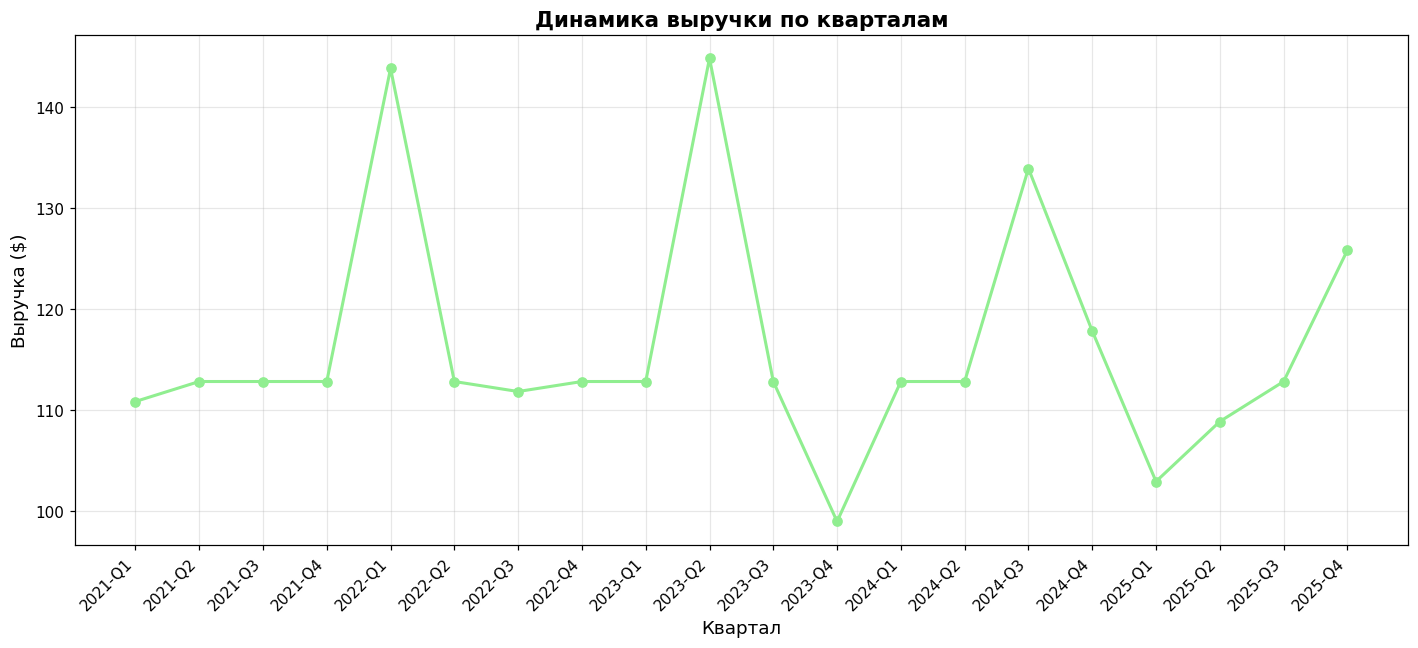

In [ ]:
# ИТОГ Q2: Выручка по кварталам. Есть ли сезонность?
# Квартал = ((CAST(strftime('%m', InvoiceDate) AS INT) - 1) / 3) + 1
# Подсказка: сгруппируйте по году + кварталу
# Визуализация: линейный или столбчатый график

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings

conn = sqlite3.connect("tgu_practice_db.db")
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["figure.dpi"]  = 110
warnings.filterwarnings("ignore")

def sql(query):
    return pd.read_sql_query(query, conn)

# TODO: SQL
query_q2 = """
SELECT 
    strftime('%Y', InvoiceDate) AS Год,
    CAST((CAST(strftime('%m', InvoiceDate) AS INTEGER) - 1) / 3 + 1 AS INTEGER) AS Квартал,
    ROUND(SUM(Total), 2) AS Выручка
FROM Invoice
GROUP BY Год, Квартал
ORDER BY Год, Квартал
"""

df_quarterly = sql(query_q2)
df_quarterly['Период'] = df_quarterly['Год'] + '-Q' + df_quarterly['Квартал'].astype(str)


# TODO: matplotlib
plt.figure(figsize=(13, 6))
plt.plot(df_quarterly['Период'], df_quarterly['Выручка'], 
         marker='o', linestyle='-', color='lightgreen', linewidth=2)

plt.xlabel('Квартал', fontsize=12)
plt.ylabel('Выручка ($)', fontsize=12)
plt.title('Динамика выручки по кварталам', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('quarterly_revenue.png', dpi=120, bbox_inches='tight')
plt.show()




### Вопрос 3: Эффективность агентов поддержки


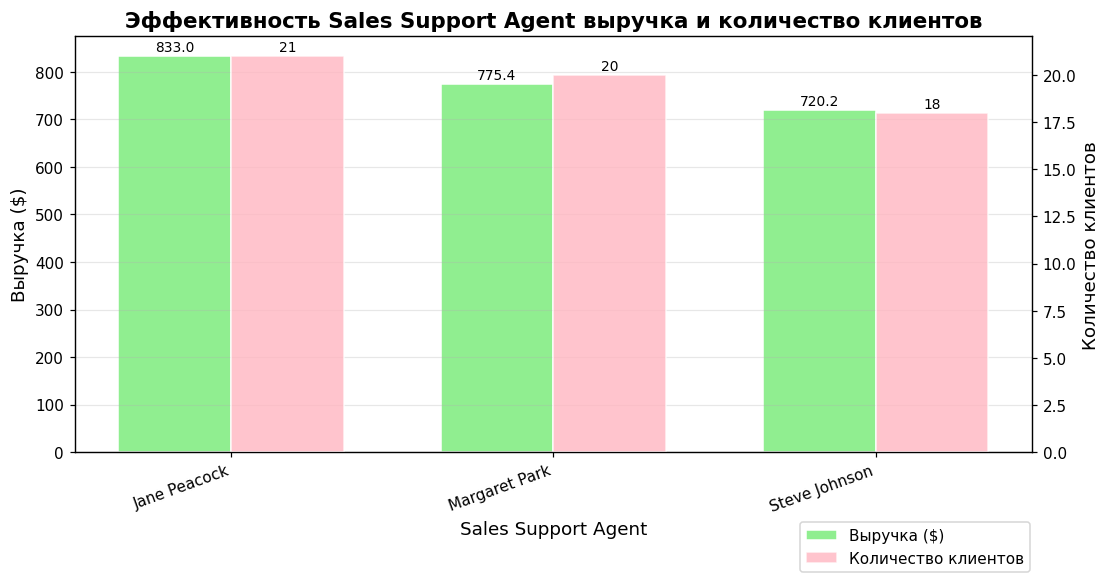

In [ ]:
# ИТОГ Q3: Кто из Sales Support Agent эффективнее?
# Метрики: кол-во клиентов, суммарная выручка, средний чек (Total/кол-во заказов)
# Таблицы: Employee → Customer → Invoice
# Визуализация: grouped bar chart (выручка + клиенты рядом)

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
import numpy as np

conn = sqlite3.connect("tgu_practice_db.db")
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["figure.dpi"]  = 110
warnings.filterwarnings("ignore")

def sql(query):
    return pd.read_sql_query(query, conn)

# TODO: SQL
query_q3 = """
SELECT 
    Employee.EmployeeId,
    Employee.FirstName || ' ' || Employee.LastName AS Agent,
    COUNT(DISTINCT Customer.CustomerId) AS Clients,
    ROUND(SUM(Invoice.Total), 2) AS Revenue,
    ROUND(SUM(Invoice.Total) / COUNT(Invoice.InvoiceId), 2) AS AvgCheck
FROM Employee
JOIN Customer ON Employee.EmployeeId = Customer.SupportRepId
JOIN Invoice ON Customer.CustomerId = Invoice.CustomerId
WHERE Employee.Title LIKE '%Sales%Agent%'
GROUP BY Employee.EmployeeId
ORDER BY Revenue DESC
"""

df_agents = sql(query_q3)

# TODO: matplotlib
agents = df_agents['Agent']
revenue = df_agents['Revenue']
clients = df_agents['Clients']

x = np.arange(len(agents))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 6))

# Столбцы выручки
bars1 = ax1.bar(x - width/2, revenue, width, label='Выручка ($)', color='lightgreen', edgecolor='white')
ax1.set_ylabel('Выручка ($)', fontsize=12)
ax1.set_xlabel('Sales Support Agent', fontsize=12)
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

# Столбцы количества клиентов 
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, clients, width, label='Количество клиентов', color='lightpink', alpha=0.8, edgecolor='white')
ax2.set_ylabel('Количество клиентов', fontsize=12)
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

# Настройка оси X
ax1.set_xticks(x)
ax1.set_xticklabels(agents, rotation=20, ha='right', fontsize=10)
ax1.set_title('Эффективность Sales Support Agent выручка и количество клиентов', fontsize=14, fontweight='bold')

# Легенда 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left',                
           bbox_to_anchor=(0.75, -0.15),    
           frameon=True)
plt.subplots_adjust(right=0.85, bottom=0.25)
# Сетка
ax1.grid(axis='y', alpha=0.3)
ax2.grid(False)

plt.savefig('agents_performance.png', dpi=120, bbox_inches='tight')
plt.show()




### Вопрос 4: Разнообразие жанров в плейлистах


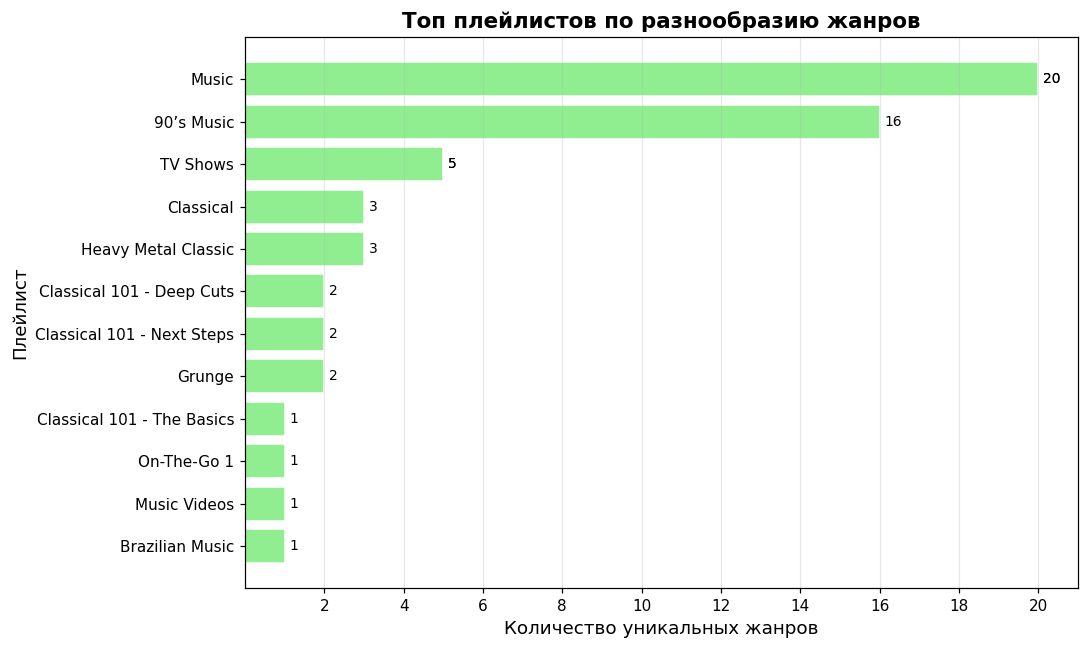

In [ ]:
# ИТОГ Q4: Какие плейлисты наиболее разнообразны по жанрам?
# Метрика: COUNT(DISTINCT GenreId) на плейлист
# Таблицы: Playlist → PlaylistTrack → Track → Genre
# Визуализация: горизонтальный bar chart

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings

conn = sqlite3.connect("tgu_practice_db.db")
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["figure.dpi"]  = 110
warnings.filterwarnings("ignore")

def sql(query):
    return pd.read_sql_query(query, conn)

# TODO: SQL
query_q4 = """
SELECT 
    Playlist.Name AS Playlist,
    COUNT(DISTINCT Track.GenreId) AS UniqueGenres
FROM Playlist
JOIN PlaylistTrack ON Playlist.PlaylistId = PlaylistTrack.PlaylistId
JOIN Track ON PlaylistTrack.TrackId = Track.TrackId
GROUP BY Playlist.PlaylistId
ORDER BY UniqueGenres DESC
"""

df_playlists = sql(query_q4)

# TODO: matplotlib
top = df_playlists.sort_values('UniqueGenres', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(top['Playlist'], top['UniqueGenres'], 
                color='lightgreen', edgecolor='white')
plt.bar_label(bars, padding=3, fontsize=9)
plt.xlabel('Количество уникальных жанров', fontsize=12)
plt.ylabel('Плейлист', fontsize=12)
plt.title('Топ плейлистов по разнообразию жанров', fontsize=14, fontweight='bold')

max_val = top['UniqueGenres'].max()
plt.xticks(range(2, max_val + 1, 2))

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('playlist_genre_diversity.png', dpi=120, bbox_inches='tight')
plt.show()




### Вопрос 5: LTV клиента по странам


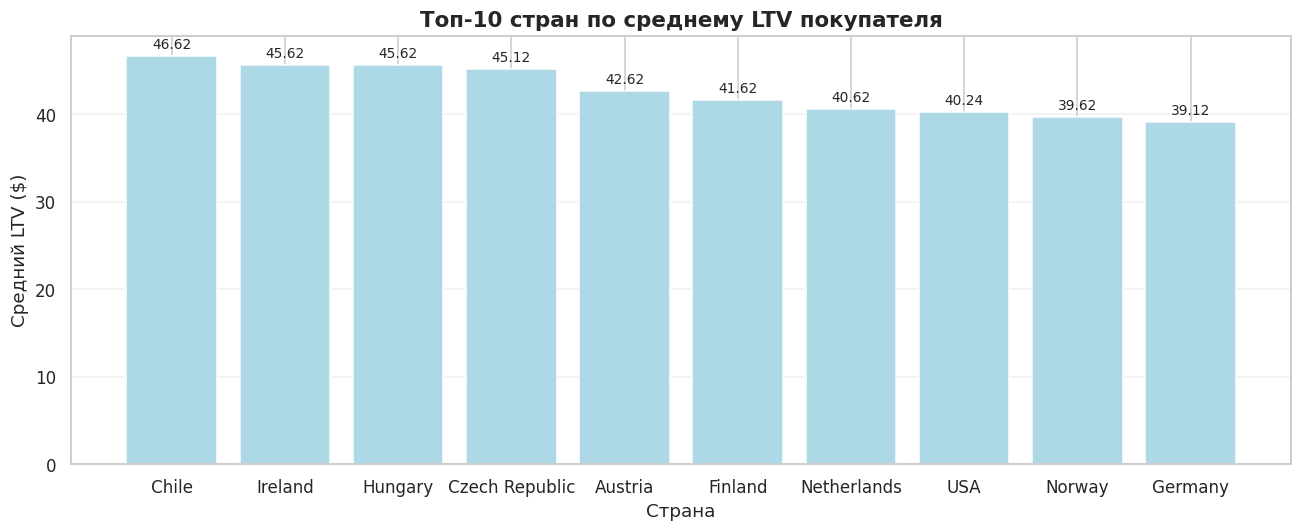

In [ ]:
# 📝 ИТОГ Q5: Среднее значение LTV покупателя по странам
# LTV = суммарная выручка с одного покупателя
# Шаги:
#   CTE 1: SUM(Total) по каждому CustomerId
#   Итог:  GROUP BY Country → AVG(LTV)
# Визуализация: топ-10 стран по среднему LTV

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings

conn = sqlite3.connect("tgu_practice_db.db")
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["figure.dpi"]  = 110
warnings.filterwarnings("ignore")

def sql(query):
    return pd.read_sql_query(query, conn)

# TODO: SQL
query_q5 = """
WITH customer_ltv AS (
    SELECT 
        c.CustomerId,
        c.Country,
        SUM(i.Total) AS LTV
    FROM Customer c
    JOIN Invoice i ON c.CustomerId = i.CustomerId
    GROUP BY c.CustomerId
)
SELECT 
    Country,
    ROUND(AVG(LTV), 2) AS AvgLTV
FROM customer_ltv
GROUP BY Country
ORDER BY AvgLTV DESC
LIMIT 10
"""
df_ltv = sql(query_q5)

# TODO: matplotlib
plt.figure(figsize=(12, 5))
bars = plt.bar(df_ltv['Country'], df_ltv['AvgLTV'], 
               color='lightblue', edgecolor='white')
plt.bar_label(bars, padding=3, fmt='%.2f', fontsize=9)

plt.xlabel('Страна', fontsize=12)
plt.ylabel('Средний LTV ($)', fontsize=12)
plt.title('Топ‑10 стран по среднему LTV покупателя', fontsize=14, fontweight='bold')
# Горизонтальные подписи стран на оси X
plt.xticks(rotation=0, ha='center')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('avg_ltv_by_country.png', dpi=120, bbox_inches='tight')
plt.show()




### HADR - seaborn / plotly (+10 баллов)


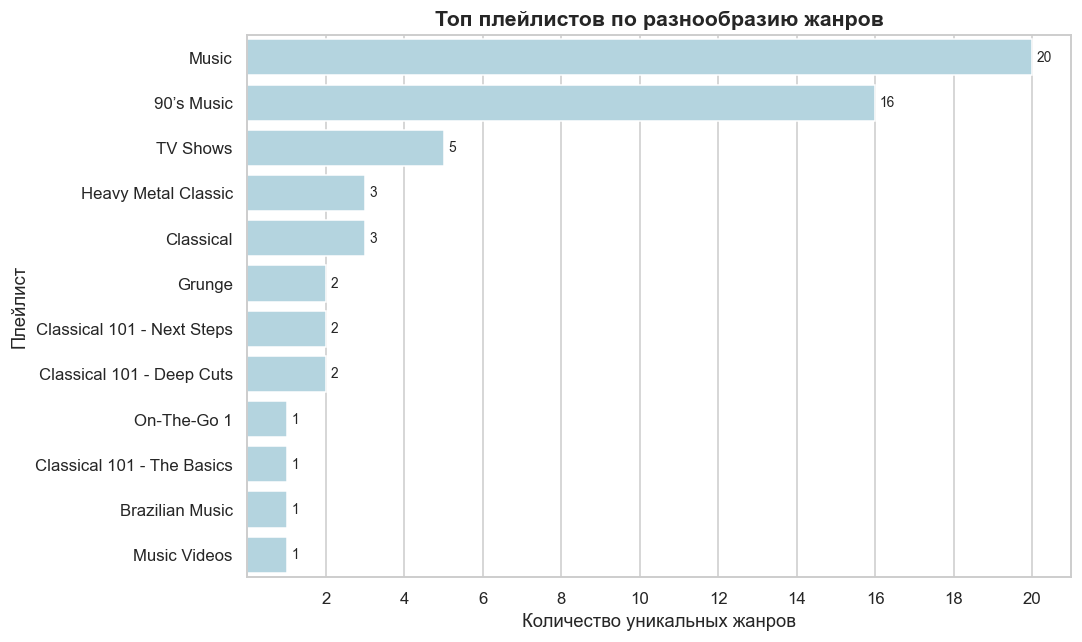

In [ ]:
# Переделайте любой из графиков с помощью seaborn или plotly

# ── Пример seaborn ──────────────────────────────────────────────────────────
# import seaborn as sns
# sns.set_theme(style="whitegrid", palette="muted")
# sns.barplot(data=df, x="Выручка_USD", y="Исполнитель")
# plt.title("Топ-10 исполнителей по выручке")
# plt.tight_layout()
# plt.show()

# ── Пример plotly ────────────────────────────────────────────────────────────
# import plotly.express as px
# fig = px.bar(df_sales, x="Месяц", y="Выручка",
#              title="Выручка по месяцам", labels={"Выручка": "Выручка ($)"})
# fig.show()

# TODO: ваш бонусный интерактивный или seaborn-график
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

conn = sqlite3.connect("tgu_practice_db.db")
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["figure.dpi"]  = 110
warnings.filterwarnings("ignore")

def sql(query):
    return pd.read_sql_query(query, conn)

query_q4 = """
SELECT 
    Playlist.Name AS Playlist,
    COUNT(DISTINCT Track.GenreId) AS UniqueGenres
FROM Playlist
JOIN PlaylistTrack ON Playlist.PlaylistId = PlaylistTrack.PlaylistId
JOIN Track ON PlaylistTrack.TrackId = Track.TrackId
GROUP BY Playlist.PlaylistId
ORDER BY UniqueGenres DESC
"""

df_playlists = sql(query_q4)

# Сртировка данных
top = df_playlists.sort_values('UniqueGenres', ascending=False)

# Установка стиля seaborn
sns.set_theme(style="whitegrid", palette="muted")

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top, x='UniqueGenres', y='Playlist', 
                 color='lightblue', edgecolor='white')

# Добавление подписей значений на концах полос
ax.bar_label(ax.containers[0], padding=3, fontsize=9)

plt.xlabel('Количество уникальных жанров', fontsize=12)
plt.ylabel('Плейлист', fontsize=12)
plt.title('Топ плейлистов по разнообразию жанров', fontsize=14, fontweight='bold')

# Настройка оси X 
max_val = top['UniqueGenres'].max()
plt.xticks(range(2, max_val + 1, 2))

plt.tight_layout()
plt.savefig('playlist_genre_diversity_seaborn.png', dpi=120, bbox_inches='tight')
plt.show()

